# Day 04 - Business Sales Analysis

## Context
For this practice I am working like a junior data analyst. Management's question is:

**"Sales look okay, but profit seems weaker than expected. Find what is happening and what we should pay attention to."**

My plan was to first check and clean the data, then compare channels and categories, and finally look deeper into discounts, returns and the monthly profit margin.

This notebook is still part of my learning process, so I kept the analysis straightforward and focused on results I can explain.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("../Data/day04_business_sales.csv")

print("Shape:", sales.shape)
print()
print("Missing values:")
print(sales.isnull().sum()[sales.isnull().sum() > 0])
print()
print("Exact duplicated rows:", sales.duplicated().sum())

Shape: (653, 14)

Missing values:
region           3
customer_type    3
dtype: int64

Exact duplicated rows: 3


### Quick data check
I found 3 exact duplicated rows. There were also only 3 missing values in `region` and 3 in `customer_type`. I decided to remove the exact duplicates and use `Unknown` for those missing categories instead of guessing a value.

In [2]:
sales = sales.drop_duplicates().copy()

sales["region"] = sales["region"].fillna("Unknown")
sales["customer_type"] = sales["customer_type"].fillna("Unknown")
sales["order_date"] = pd.to_datetime(sales["order_date"])

print("Rows after cleaning:", len(sales))
print("Remaining duplicates:", sales.duplicated().sum())
print("Missing values left:", sales.isnull().sum().sum())
print("Date range:", sales["order_date"].min().date(), "to", sales["order_date"].max().date())

Rows after cleaning: 650
Remaining duplicates: 0
Missing values left: 0
Date range: 2026-01-01 to 2026-06-30


In [3]:
# a small numeric check after cleaning
sales[["units_sold", "discount_pct", "net_sales", "profit"]].describe().round(2)

,units_sold,discount_pct,net_sales,profit
count,650.00,650.00,650.00,650.00
mean,4.08,11.65,203.19,71.66
std,2.21,8.11,179.12,76.41
min,1.00,0.00,1.40,-370.49
25%,2.00,5.00,66.27,30.21
50%,4.00,10.00,148.88,59.10
75%,6.00,20.00,296.69,102.41
max,11.00,30.00,954.56,424.40


## Overall numbers
I am using `net_sales` for the profitability calculations because it is the sales revenue left after the discount/return adjustment in this dataset.

In [4]:
total_net_sales = sales["net_sales"].sum()
total_profit = sales["profit"].sum()
profit_margin = total_profit / total_net_sales * 100

print("Total Net Sales:", round(total_net_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin (%):", round(profit_margin, 2))

Total Net Sales: 132070.43
Total Profit: 46576.73
Profit Margin (%): 35.27


## Channel analysis
I started with channel because I wanted to see if one part of the business was weaker than the others. I also added average discount and return rate because they could help explain the margin differences.

In [5]:
sales["is_returned"] = sales["returned"].eq("Yes")

channel_analysis = sales.groupby("channel")[["net_sales", "profit"]].sum()
channel_analysis["profit_margin"] = channel_analysis["profit"] / channel_analysis["net_sales"] * 100
channel_analysis["avg_discount"] = sales.groupby("channel")["discount_pct"].mean()
channel_analysis["return_rate"] = sales.groupby("channel")["is_returned"].mean() * 100

print(channel_analysis.round(2))

           net_sales    profit  profit_margin  avg_discount  return_rate
channel                                                                 
Online      49140.08  16172.29          32.91         12.94         6.13
Retail      43605.50  14932.53          34.24         10.25         5.38
Wholesale   39324.85  15471.91          39.34         10.90         0.00


Online stood out here. It had the lowest profit margin, while also having the highest average discount and the highest return rate. That is why I focused more on discounts and returns next.

In [6]:
category_analysis = sales.groupby("category")[["net_sales", "profit"]].sum()
category_analysis["profit_margin"] = category_analysis["profit"] / category_analysis["net_sales"] * 100

print(category_analysis.round(2))

             net_sales    profit  profit_margin
category                                       
Accessories   18879.84   9654.81          51.14
Electronics   53587.29  19877.08          37.09
Home          59603.30  17044.84          28.60


The Home category had the lowest category margin. This tells me category/product mix can also matter, so I should not assume discounts and returns are the only reasons.

## Discount analysis
Now I grouped the orders by discount level. I am comparing margin, not just total profit, because the number and size of orders are different at each discount level.

In [7]:
discount_analysis = sales.groupby("discount_pct")[["net_sales", "profit"]].sum()
discount_analysis["profit_margin"] = discount_analysis["profit"] / discount_analysis["net_sales"] * 100

print(discount_analysis.round(2))

              net_sales    profit  profit_margin
discount_pct                                    
0.0            24558.87  10993.87          44.77
5.0            26387.21  10310.65          39.07
10.0           30899.11  12008.61          38.86
15.0           22703.67   6813.33          30.01
20.0           13763.71   3314.66          24.08
25.0           12597.65   2992.79          23.76
30.0            1160.21    142.82          12.31


The higher discount groups generally had lower profit margins, especially from 15% and above. This is an association in this data, not proof that discount alone caused the lower margin.

## Return analysis
I also wanted to see how different a returned order is financially from a normal order.

In [8]:
return_analysis = sales.groupby("returned")[["net_sales", "profit"]].agg(["sum", "mean"])
print(return_analysis.round(2))

          net_sales            profit        
                sum    mean       sum    mean
returned                                     
No        131364.24  212.22  49812.06   80.47
Yes          706.19   22.78  -3235.33 -104.37


Returned orders were clearly damaging in this dataset. They produced negative profit as a group and also had negative average profit per returned order.

In [9]:
discount_return_analysis = pd.DataFrame({
    "return_rate": sales.groupby("discount_pct")["is_returned"].mean() * 100,
    "order_count": sales.groupby("discount_pct")["order_id"].count()
})

print(discount_return_analysis.round(2))

              return_rate  order_count
discount_pct                          
0.0                  2.88          104
5.0                  6.09          115
10.0                 2.67          150
15.0                 3.60          111
20.0                10.42           96
25.0                 3.23           62
30.0                 8.33           12


The 20% discount group had the highest observed return rate (about 10.4%) and it had 96 orders, so it is worth noticing. But the return rate did not increase consistently with discount level, so I cannot say that higher discounts always mean more returns.

### Checking discounts without returned orders
To check if returns were the whole reason for the discount-margin pattern, I repeated the discount analysis using only non-returned orders.

In [10]:
non_returned = sales[sales["returned"] == "No"]

non_returned_discount = non_returned.groupby("discount_pct")[["net_sales", "profit"]].sum()
non_returned_discount["profit_margin"] = (
    non_returned_discount["profit"] / non_returned_discount["net_sales"] * 100
)

print(non_returned_discount.round(2))

              net_sales    profit  profit_margin
discount_pct                                    
0.0            24527.04  11109.44          45.29
5.0            26251.85  10790.67          41.10
10.0           30818.37  12332.24          40.02
15.0           22513.95   7768.74          34.51
20.0           13552.08   4367.37          32.23
25.0           12555.24   3213.76          25.60
30.0            1145.71    229.84          20.06


The margin still generally falls as the discount gets higher even after removing returned orders. So returns hurt profit, but they do not fully explain the lower margins at higher discounts.

## Profit margin over time
Last, I checked the monthly margin to see if management's concern also appears over the six-month period.

In [11]:
sales["month"] = sales["order_date"].dt.to_period("M")

monthly_analysis = sales.groupby("month")[["net_sales", "profit"]].sum()
monthly_analysis["profit_margin"] = monthly_analysis["profit"] / monthly_analysis["net_sales"] * 100

print(monthly_analysis.round(2))

         net_sales   profit  profit_margin
month                                     
2026-01   19128.53  7209.33          37.69
2026-02   24133.30  8849.41          36.67
2026-03   24678.20  8760.88          35.50
2026-04   20865.01  6823.20          32.70
2026-05   21718.93  7693.82          35.42
2026-06   21546.46  7240.09          33.60


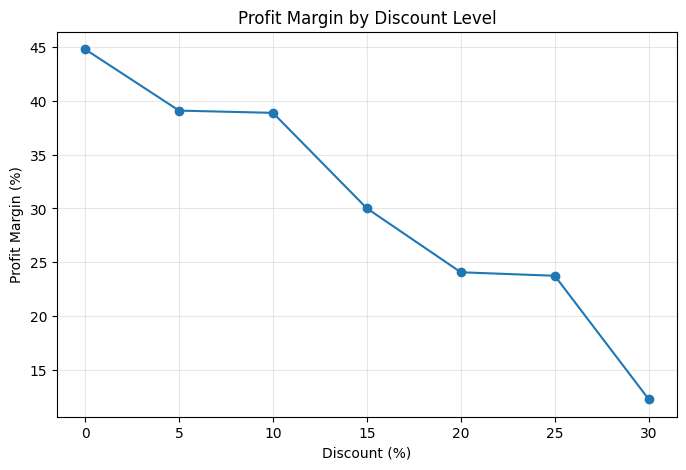

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(discount_analysis.index, discount_analysis["profit_margin"], marker="o")
plt.title("Profit Margin by Discount Level")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")
plt.grid(alpha=0.3)
plt.show()

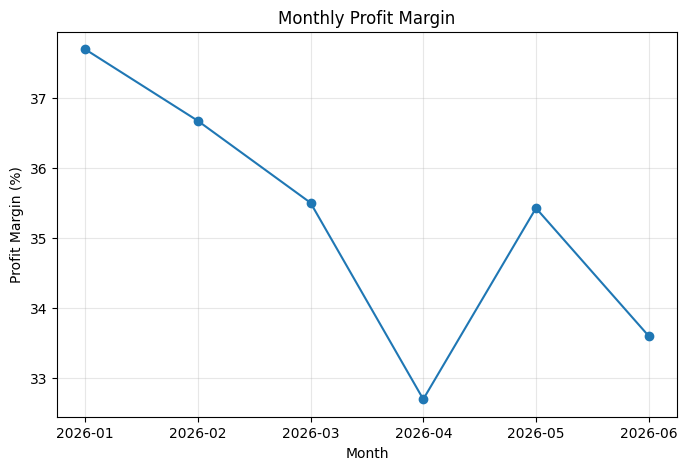

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_analysis.index.astype(str), monthly_analysis["profit_margin"], marker="o")
plt.title("Monthly Profit Margin")
plt.xlabel("Month")
plt.ylabel("Profit Margin (%)")
plt.grid(alpha=0.3)
plt.show()

## What I found

- Total **net sales** were about **132,070**, total profit was about **46,577**, and the overall profit margin was **35.27%**.
- **Online** was the weakest channel by margin at about **32.91%**. It also had the highest average discount (**12.94%**) and the highest channel return rate (**6.13%**), so this is the channel I would pay the most attention to.
- The **Home** category had the lowest category margin at about **28.60%**.
- Higher discount levels were generally associated with lower profit margins. For example, the 0% discount group had about **44.77%** margin, while the 20% group had about **24.08%**. The pattern still existed after removing returned orders.
- Returned orders were very costly: returned orders produced about **-3,235** total profit, and around **-104** average profit per returned order. Non-returned orders averaged about **+80** profit.
- The **20% discount** group had the highest observed return rate at about **10.42%** across **96 orders**, but return rates were irregular across discount levels. I would not claim that discounts caused returns from this alone.
- Monthly margin weakened overall from **37.69% in January** to **33.60% in June**, with the lowest point in **April (32.70%)**. It was not a straight decline because May recovered a bit.

### My conclusion
Management's concern is supported by the data because margins generally weakened over the period. The biggest things I found were the losses from returned orders and the strong relationship between higher discounts and lower margins, with Online standing out the most. I still cannot say these are the only causes, and without a target margin or an older period to compare against I cannot say the company's margin is definitely "bad".

If I continued this analysis, I would investigate **why Online returns happen**, review the heavier discount levels, and keep tracking **profit margin together with sales instead of only looking at sales totals**.